# **NIVEL BÁSICO**
Analizaremos un conjunto de datos sobre indicadores de salud relacionados con la diabetes, y construiremos modelos predictivos para clasificar a las personas en saludables o prediabéticas/diabéticas.

## Carga y exploración de los datos

Cargamos el dataset directamente desde el repositorio de UCI mediante la librería `ucimlrepo`. A continuación, se realiza una exploración inicial para entender sus características.


In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

X.head()
y.head()

,Diabetes_binary
0,0
1,0
2,0
3,0
4,0


### Análisis exploratorio

En esta sección se analizan los tipos de variables y los valores faltantes


Ahora que ya tenemos las variables filtradas, vamos a:

    Ver qué columnas son numéricas o categóricas.

    Comprobar si hay valores nulos.

In [ ]:
# 1. Ver los tipos de datos de cada columna
print("\nTipos de datos:")
print(X.dtypes)
print(y.dtypes)

# 2. Ver si hay valores nulos
print("\nValores nulos por columna:")
print(X.isnull().sum())
print(y.isnull().sum())


Tipos de datos:
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object
Diabetes_binary    int64
dtype: object

Valores nulos por columna:
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholCo

Comprobar si las columnas binarias tiene solo valores 0 o 1

In [ ]:
binarias_X = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

for col in binarias_X:
    valores_unicos = X[col].unique()
    if not set(valores_unicos).issubset({0, 1}):
        print(f"{col} contiene valores diferentes de 0 y 1: {valores_unicos}")

valores_unicos_y = y['Diabetes_binary'].unique()
if not set(valores_unicos_y).issubset({0, 1}):
    print(f"Diabetes_binary contiene valores diferentes de 0 y 1: {valores_unicos_y}")

Comprobar si las columnas no binarias que tienen rangos definidos tienen valores fuera de ese rango

In [ ]:
rango_valido = {
    'GenHlth': list(range(1, 6)),           # 1 a 5
    'MentHlth': list(range(0, 31)),         # 0 a 30
    'PhysHlth': list(range(0, 31)),         # 0 a 30
    'Age': list(range(1, 14)),              # 1 a 13
    'Education': list(range(1, 7)),         # 1 a 6
    'Income': list(range(1, 9))             # 1 a 8
}

# Verificar si hay valores fuera del rango en cada variable
for col, valid_values in rango_valido.items():
    invalid = X[~X[col].isin(valid_values)]
    if not invalid.empty:
        print(f"Valores no válidos encontrados en '{col}':")
        print(invalid[col].value_counts())

La unica variable que no es binaria ni tiene rango especificado en Kaggle es el BMI asi que vamos a estudiar sus valores

In [ ]:
valores_bmi = X['BMI']

# Definir un rango lógico para BMI (por ejemplo, entre 10 y 60)
rango_bmi_valido = (valores_bmi >= 10) & (valores_bmi <= 60)

# Comprobar si hay valores fuera de rango
valores_fuera_de_rango = valores_bmi[~rango_bmi_valido]

if not valores_fuera_de_rango.empty:
    print(f"Valores de BMI fuera del rango razonable: {valores_fuera_de_rango.unique()}")
else:
    print("Todos los valores de BMI están dentro del rango razonable.")


Valores de BMI fuera del rango razonable: [63 61 74 62 64 66 73 85 67 65 70 82 79 92 68 72 88 96 81 71 75 77 69 76
 87 89 84 95 98 91 86 83 80 90 78]


### Visualiza los datos
Utilizamos gráficos para entender la distribución de las variables y la relación entre ellas. Como todas las variables son numéricas se hace de esta manera.


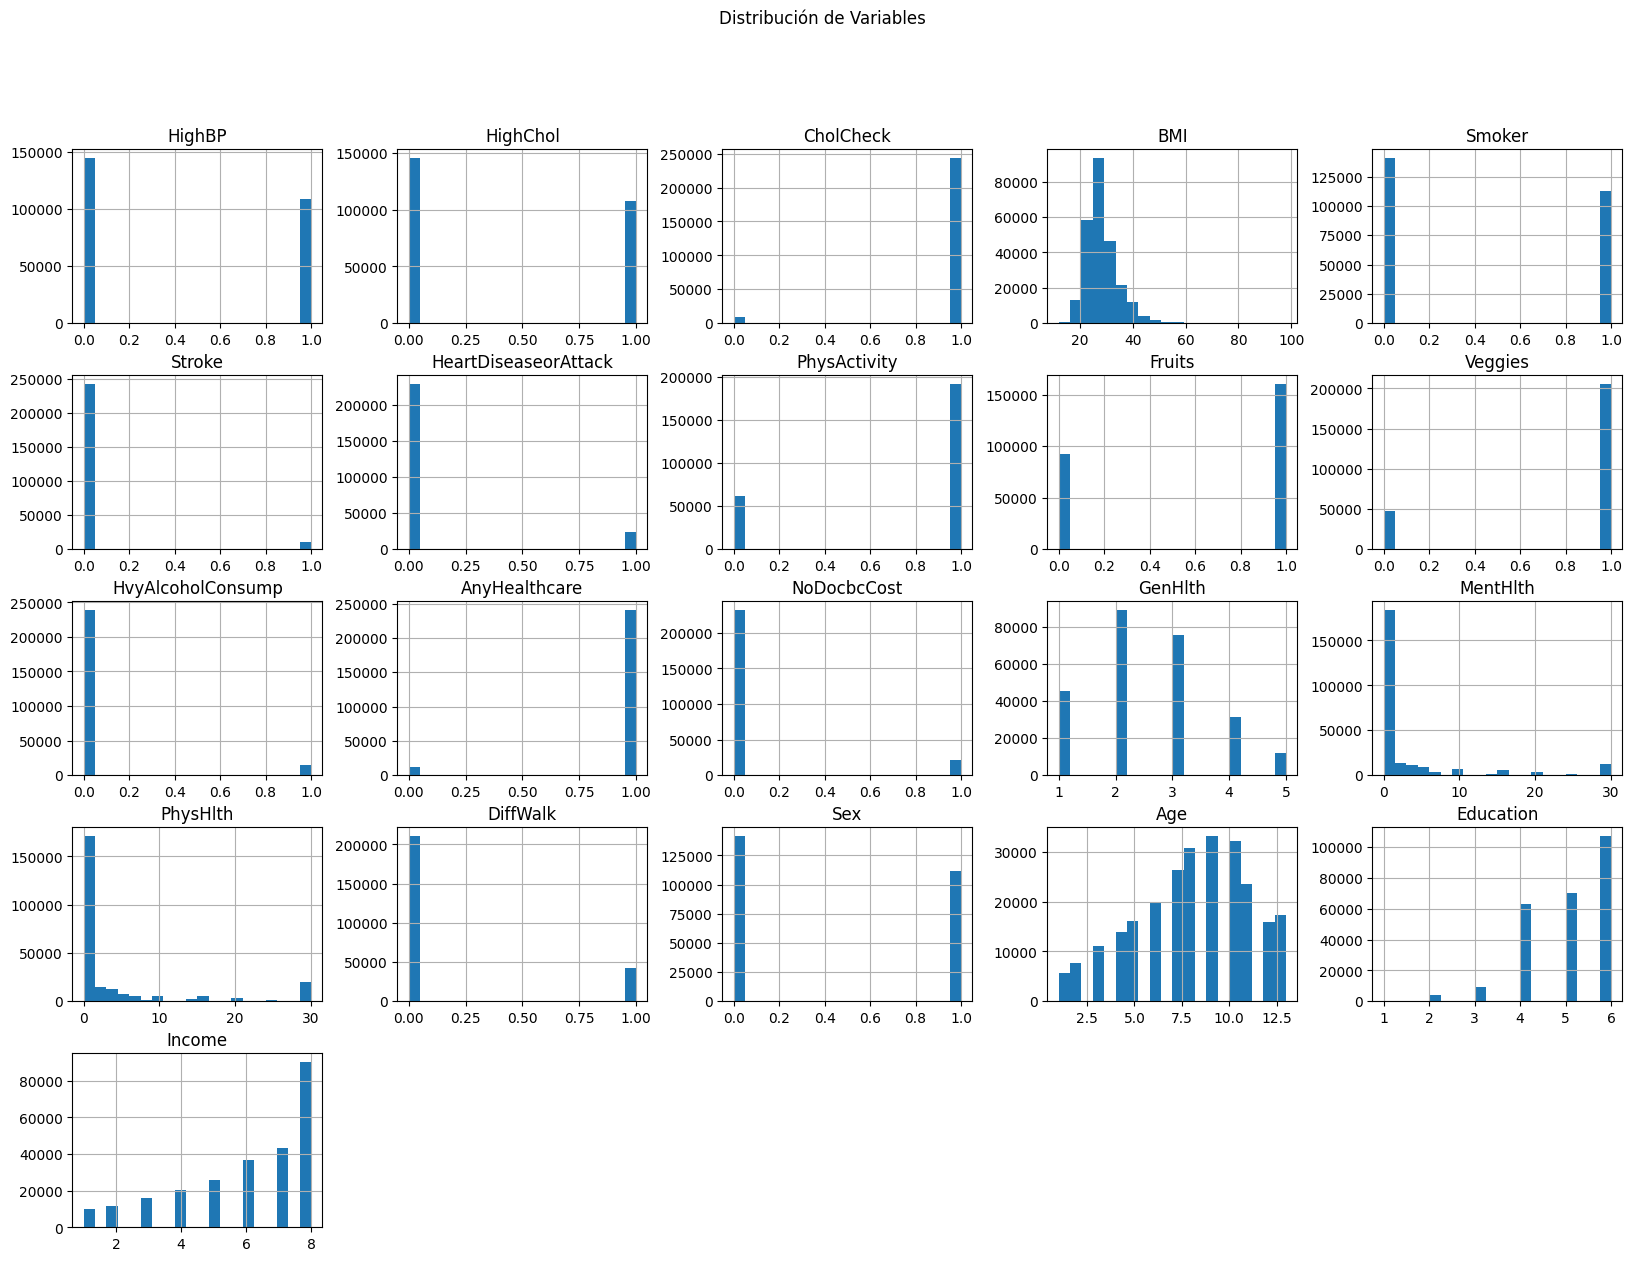

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribución de las variables
X.hist(figsize=(20, 14), bins=20)
plt.suptitle("Distribución de Variables")
plt.show()

Matriz de correlación

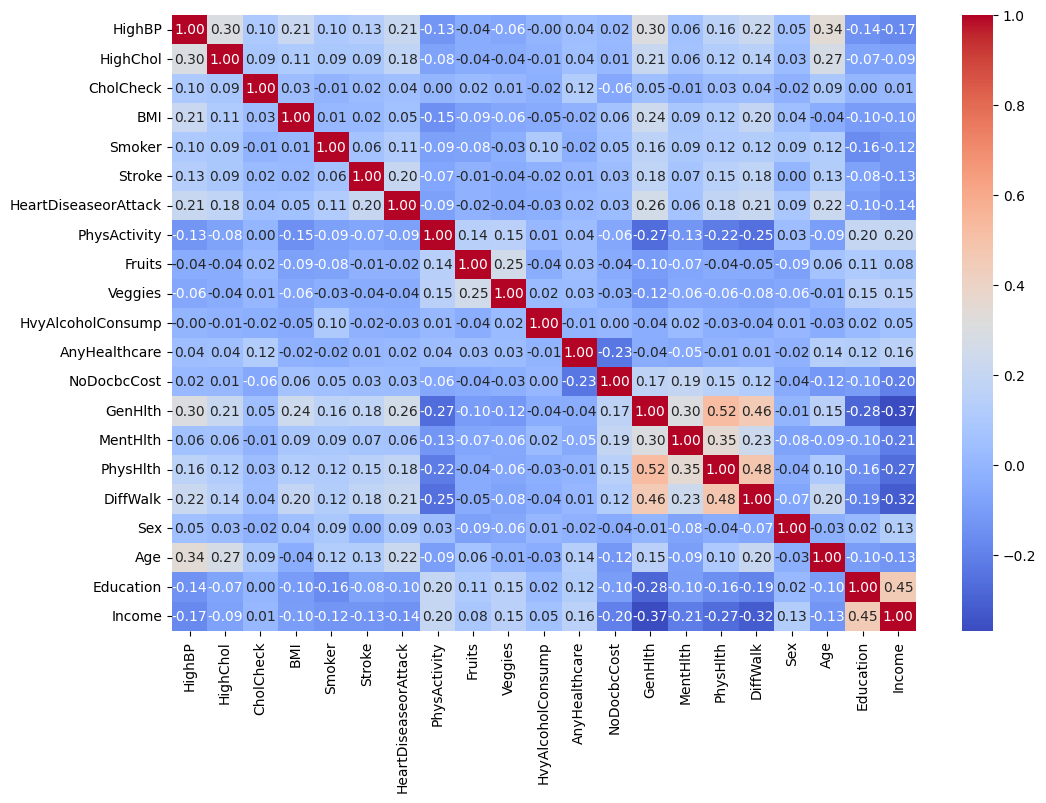

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Calcula la matriz de correlación
corr_matrix = X.corr()

# Muestra la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


### Desequilibrio de clases

Vamos a determinar cuántas instancias hay en cada categoría de la variable objetivo y a analizar cómo esto puede afectar el rendimiento de los modelos

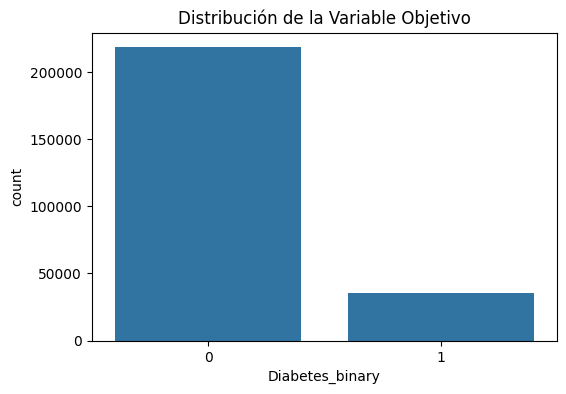

Distribución de clases:
Diabetes_binary
0                  218334
1                   35346
Name: count, dtype: int64

Distribución porcentual de las clases:
Diabetes_binary
0                  86.066698
1                  13.933302
Name: proportion, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualización de la distribución de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(x=y["Diabetes_binary"])
plt.title("Distribución de la Variable Objetivo")
plt.show()

# Distribución de clases en números absolutos
print("Distribución de clases:")
print(y.value_counts())

# Distribución porcentual
print("\nDistribución porcentual de las clases:")
print(y.value_counts(normalize=True) * 100)


Es importante eliminar las variables que podrían no aportar valor al modelo, es decir, variables que no influyen en la diabetes.

In [ ]:
X = X.drop(columns=[
    "CholCheck", "AnyHealthcare","NoDocbcCost",
    "GenHlth", "MentHlth", "PhysHlth", "Education", "Income"
])
X.head()

,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,DiffWalk,Sex,Age
0,1,1,40,1,0,0,0,0,1,0,1,0,9
1,0,0,25,1,0,0,1,0,0,0,0,0,7
2,1,1,28,0,0,0,0,1,0,0,1,0,9
3,1,0,27,0,0,0,1,1,1,0,0,0,11
4,1,1,24,0,0,0,1,1,1,0,0,0,11


## Evaluación de un modelo básico

### DummyClassifier
Como punto de partida, usamos un modelo de referencia (DummyClassifier) que simplemente predice siempre la clase más frecuente.

Esto nos permite establecer una línea base para comparar el rendimiento de modelos más avanzados.

Calculamos el AUC (Área bajo la curva ROC) para evaluar el rendimiento del modelo base.
Este modelo predice siempre la clase mayoritaria. Su AUC se usará como línea base para comparar con modelos más complejos.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix


# Crear el clasificador Dummy
dummy = DummyClassifier(strategy='most_frequent')

# Definir la validación cruzada (StratifiedKFold)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Realizar validación cruzada y obtener predicciones
y_pred = cross_val_predict(dummy, X, y, cv=cv)

# Mostrar la matriz de confusión
print("\nMatriz de Confusión :")
print(confusion_matrix(y, y_pred))

# Mostrar el reporte de clasificación
print("Reporte de clasificación:")
print(classification_report(y, y_pred, zero_division=0))



# Calcular y mostrar AUC y Accuracy con 10-CV
acc_cv = cross_val_score(dummy, X, y, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(dummy, X, y, cv=cv, scoring='roc_auc')

print(f"\nDummyClassifier - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"DummyClassifier - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")



Matriz de Confusión :
[[218334      0]
 [ 35346      0]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93    218334
           1       0.00      0.00      0.00     35346

    accuracy                           0.86    253680
   macro avg       0.43      0.50      0.46    253680
weighted avg       0.74      0.86      0.80    253680


DummyClassifier - Accuracy promedio (10-CV): 0.860666982024598 ± 1.931165044763883e-05
DummyClassifier - AUC promedio (10-CV): 0.5 ± 0.0


## Clasificadores básicos

### Clasificadores SIN PARÁMETROS
Experimenta con algoritmos de clasificación estudiados en los  cuadernos de Python de prácticas u otros que puedan tener un buen rendimiento.

#### LogisticRegression



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo de regresión logística
logreg = LogisticRegression(max_iter=1000)

# Obtener predicciones con validación cruzada
y_pred = cross_val_predict(logreg, X, y, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - Logistic Regression:")
print(confusion_matrix(y, y_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - Logistic Regression:")
print(classification_report(y, y_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(logreg, X, y, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(logreg, X, y, cv=cv, scoring='roc_auc')

print(f"\nLogistic Regression - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Logistic Regression - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")



Matriz de Confusión - Logistic Regression:
[[214701   3633]
 [ 31262   4084]]

Reporte de Clasificación - Logistic Regression:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92    218334
           1       0.53      0.12      0.19     35346

    accuracy                           0.86    253680
   macro avg       0.70      0.55      0.56    253680
weighted avg       0.83      0.86      0.82    253680


Logistic Regression - Accuracy promedio (10-CV): 0.862444812362031 ± 0.0010801656530490804
Logistic Regression - AUC promedio (10-CV): 0.799812601504774 ± 0.004345422126647894


#### RandomForestClassifier


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo Random Forest
rf = RandomForestClassifier(n_estimators=10, random_state=42)

# Obtener predicciones con validación cruzada
y_pred = cross_val_predict(rf, X, y, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - Random Forest:")
print(confusion_matrix(y, y_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - Random Forest:")
print(classification_report(y, y_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')

print(f"\nRandom Forest - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Random Forest - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")



Matriz de Confusión - Random Forest:
[[206252  12082]
 [ 28116   7230]]

Reporte de Clasificación - Random Forest:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91    218334
           1       0.37      0.20      0.26     35346

    accuracy                           0.84    253680
   macro avg       0.63      0.57      0.59    253680
weighted avg       0.81      0.84      0.82    253680


Random Forest - Accuracy promedio (10-CV): 0.8415405234941659 ± 0.0015501334023801429
Random Forest - AUC promedio (10-CV): 0.7078964157297766 ± 0.002760746312619812


### Ajuste de los parámetros


In [ ]:
from sklearn.model_selection import train_test_split

# X: características (features)
# y: etiquetas (labels)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)


#### Ajuste para LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from scipy.stats import loguniform, randint
import numpy as np

# Definir el modelo base
logreg = LogisticRegression(random_state=42)

# Espacio de hiperparámetros a explorar
param_distributions = {
    'C': loguniform(0.001, 100),          # Regularización (usando una distribución logarítmica)
    'penalty': ['l1', 'l2'],              # Tipo de penalización
    'solver': ['liblinear', 'saga'],      # Algoritmos de optimización
    'max_iter': randint(100, 2000),       # Número máximo de iteraciones
    'tol': loguniform(1e-5, 1e-1),        # Tolerancia para la convergencia
}

# Configurar RandomizedSearchCV
random_search_logreg = RandomizedSearchCV(
    estimator=logreg,
    param_distributions=param_distributions,
    n_iter=15,                    # 15 combinaciones aleatorias
    scoring='roc_auc',            # AUC como métrica de optimización
    n_jobs=-1,                    # Usa todos los núcleos de CPU
    cv=5,                         # Validación cruzada de 5 particiones
    random_state=42,
    verbose=2
)

# Ejecutar la búsqueda de los mejores hiperparámetros
y_train = y_train.values.ravel()  # Convertir a vector unidimensional si es necesario
random_search_logreg.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros encontrados para Regresión Logística:")
print(random_search_logreg.best_params_)

# Entrenar el modelo final con los mejores hiperparámetros
best_logreg = random_search_logreg.best_estimator_

# Evaluar el modelo final con validación cruzada (10 folds)
auc_scores_logreg = cross_val_score(best_logreg, X, y, cv=10, scoring='roc_auc')

# Mostrar el resultado final de AUC
print(f"AUC promedio del modelo de Regresión Logística final (10-CV): {np.mean(auc_scores_logreg)} ± {np.std(auc_scores_logreg)}")



Fitting 5 folds for each of 15 candidates, totalling 75 fits
Mejores hiperparámetros encontrados para Regresión Logística:
{'C': np.float64(0.004982752357076452), 'max_iter': 1599, 'penalty': 'l2', 'solver': 'saga', 'tol': np.float64(8.532678095658718e-05)}
AUC promedio del modelo de Regresión Logística final (10-CV): 0.8001651408005372 ± 0.005190512599385423


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Definir la validación cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo de regresión logística
logreg = LogisticRegression(
    C=np.float64(0.004982752357076452),
    max_iter=1599,
    penalty='l2',
    solver='saga',
    tol=np.float64(8.532678095658718e-05)
)


# Obtener predicciones con validación cruzada
y_pred = cross_val_predict(logreg, X, y, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - Logistic Regression:")
print(confusion_matrix(y, y_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - Logistic Regression:")
print(classification_report(y, y_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(logreg, X, y, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(logreg, X, y, cv=cv, scoring='roc_auc')

print(f"\nLogistic Regression - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Logistic Regression - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")



Matriz de Confusión - Logistic Regression:
[[214887   3447]
 [ 31485   3861]]

Reporte de Clasificación - Logistic Regression:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92    218334
           1       0.53      0.11      0.18     35346

    accuracy                           0.86    253680
   macro avg       0.70      0.55      0.55    253680
weighted avg       0.82      0.86      0.82    253680


Logistic Regression - Accuracy promedio (10-CV): 0.8622989593188268 ± 0.0009978412820708291
Logistic Regression - AUC promedio (10-CV): 0.7999836726648197 ± 0.004284921912840723


#### Ajuste para RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from scipy.stats import randint
import numpy as np

# Definir el modelo base
rf = RandomForestClassifier(random_state=42)

# Espacio de hiperparámetros a explorar
param_distributions = {
    'n_estimators': randint(100, 300),         # número de árboles
    'max_depth': randint(5, 13),               # profundidad máxima
    'min_samples_split': randint(2, 20),       # mínimo de muestras para dividir un nodo
    'min_samples_leaf': randint(1, 20),        # mínimo de muestras en una hoja
    'max_features': ['sqrt', 'log2', None],    # máximo número de características consideradas
    'bootstrap': [True, False]                 # usar bootstrap o no
}

# Configurar RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=15,            # 15 combinaciones aleatorias
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,                # validación cruzada de 5 particiones
    random_state=42,
    verbose=2
)

# Ejecutar la búsqueda de los mejores hiperparámetros
y_train = y_train.values.ravel()  # Convertir a vector unidimensional si es necesario
random_search_rf.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros
print("Mejores hiperparámetros encontrados para Random Forest:")
print(random_search_rf.best_params_)

# Entrenar el modelo final con los mejores hiperparámetros
best_rf = random_search_rf.best_estimator_

# Evaluar el modelo final
auc_scores_rf = cross_val_score(best_rf, X, y, cv=10, scoring='roc_auc')
print(f"AUC promedio del Random Forest final (10-CV): {np.mean(auc_scores_rf)} ± {np.std(auc_scores_rf)}")



Fitting 5 folds for each of 15 candidates, totalling 75 fits
Mejores hiperparámetros encontrados para Random Forest:
{'bootstrap': True, 'max_depth': 11, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 15, 'n_estimators': 108}
AUC promedio del Random Forest final (10-CV): 0.8060552409696407 ± 0.004701749446965117


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10)

# Crear el modelo Random Forest con class_weight
rf_model = RandomForestClassifier(
    bootstrap=True,
    max_depth=11,
    max_features='log2',
    min_samples_leaf=4,
    min_samples_split=15,
    n_estimators=108,
    random_state=42
)

# Obtener predicciones con validación cruzada
y_pred = cross_val_predict(rf_model, X, y, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - Random Forest:")
print(confusion_matrix(y, y_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - Random Forest:")
print(classification_report(y, y_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')

print(f"\nRandom Forest - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Random Forest - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")



Matriz de Confusión - Random Forest:
[[216061   2273]
 [ 32052   3294]]

Reporte de Clasificación - Random Forest:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93    218334
           1       0.59      0.09      0.16     35346

    accuracy                           0.86    253680
   macro avg       0.73      0.54      0.54    253680
weighted avg       0.83      0.86      0.82    253680


Random Forest - Accuracy promedio (10-CV): 0.8646917376222012 ± 0.0008669206881095162
Random Forest - AUC promedio (10-CV): 0.8059473339594673 ± 0.005182605194371904


## Balanceo de clases
Aplica técnicas de oversampling (por ejemplo, SMOTE) o undersampling
solo en el conjunto de entrenamiento.

### SMOTE (oversampling)

#### SMOTE LogisticRegression

##### Sin hiperparámetros

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE

# 1. SMOTE sobre el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote = y_train_smote.values.ravel()

# 2. Entrenar el modelo
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_smote, y_train_smote)

# 3. Predecir sobre el conjunto de test original
y_pred = logreg.predict(X_test)

# 4. Matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:\n", conf_mat)

# 5. Reporte de clasificación
report = classification_report(y_test, y_pred, zero_division=0)
print("\nReporte de Clasificación:\n", report)

# 6. 10-CV para Accuracy
acc_cv = cross_val_score(logreg, X_train_smote, y_train_smote, cv=10, scoring='accuracy')

# 7. 10-CV para AUC
auc_cv = cross_val_score(logreg, X_train_smote, y_train_smote, cv=10, scoring='roc_auc')

print(f"\nLogistic Regression - Accuracy promedio (10-CV) con SMOTE: {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Logistic Regression - AUC promedio (10-CV) con SMOTE: {auc_cv.mean()} ± {auc_cv.std()}")

Matriz de Confusión:
 [[45434 20171]
 [ 2574  7925]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      0.69      0.80     65605
           1       0.28      0.75      0.41     10499

    accuracy                           0.70     76104
   macro avg       0.61      0.72      0.61     76104
weighted avg       0.85      0.70      0.75     76104


Logistic Regression - Accuracy promedio (10-CV) con SMOTE: 0.7184948384751374 ± 0.003262395882086003
Logistic Regression - AUC promedio (10-CV) con SMOTE: 0.7885868553735684 ± 0.002868448874418567


##### Con hiperparámetros

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. SMOTE sobre el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote = y_train_smote.values.ravel()

# 2. Entrenar el modelo
logreg = LogisticRegression(
    C=np.float64(0.004982752357076452),
    max_iter=1599,
    penalty='l2',
    solver='saga',
    tol=np.float64(8.532678095658718e-05)
)

logreg.fit(X_train_smote, y_train_smote)

# 3. Predecir sobre el conjunto de test original
y_pred = logreg.predict(X_test)

# 4. Matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:\n", conf_mat)

# 5. Reporte de clasificación
report = classification_report(y_test, y_pred, zero_division=0)
print("\nReporte de Clasificación:\n", report)

# 6. 10-CV para Accuracy
acc_cv = cross_val_score(logreg, X_train_smote, y_train_smote, cv=10, scoring='accuracy')

# 7. 10-CV para AUC
auc_cv = cross_val_score(logreg, X_train_smote, y_train_smote, cv=10, scoring='roc_auc')

print(f"\nLogistic Regression - Accuracy promedio (10-CV) con SMOTE: {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Logistic Regression - AUC promedio (10-CV) con SMOTE: {auc_cv.mean()} ± {auc_cv.std()}")

Matriz de Confusión:
 [[45469 20136]
 [ 2571  7928]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      0.69      0.80     65605
           1       0.28      0.76      0.41     10499

    accuracy                           0.70     76104
   macro avg       0.61      0.72      0.61     76104
weighted avg       0.85      0.70      0.75     76104


Logistic Regression - Accuracy promedio (10-CV) con SMOTE: 0.7185570386735731 ± 0.003317788987480004
Logistic Regression - AUC promedio (10-CV) con SMOTE: 0.7886684405191349 ± 0.0032113815627620697


#### SMOTE RandomForestClassifier

##### Sin hiperparámetros

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE

# 1. SMOTE sobre el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote = y_train_smote.values.ravel()

# 2. Entrenar el modelo
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

# 3. Predecir sobre el conjunto de test original
y_pred = rf_model.predict(X_test)

# 4. Matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:\n", conf_mat)

# 5. Reporte de clasificación
report = classification_report(y_test, y_pred, zero_division=0)
print("\nReporte de Clasificación:\n", report)

# 6. 10-CV para Accuracy
acc_cv = cross_val_score(rf_model, X_train_smote, y_train_smote, cv=10, scoring='accuracy')

# 7. 10-CV para AUC
auc_cv = cross_val_score(rf_model, X_train_smote, y_train_smote, cv=10, scoring='roc_auc')

print(f"\nRandom Forest - Accuracy promedio (10-CV) con SMOTE: {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Random Forest - AUC promedio (10-CV) con SMOTE: {auc_cv.mean()} ± {auc_cv.std()}")

Matriz de Confusión:
 [[50067 15538]
 [ 5169  5330]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.91      0.76      0.83     65605
           1       0.26      0.51      0.34     10499

    accuracy                           0.73     76104
   macro avg       0.58      0.64      0.58     76104
weighted avg       0.82      0.73      0.76     76104


Random Forest - Accuracy promedio (10-CV) con SMOTE: 0.8084385065920399 ± 0.010310499214734791
Random Forest - AUC promedio (10-CV) con SMOTE: 0.8876166722679347 ± 0.009460544475296722


##### Con hiperparámetros

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE

# 1. SMOTE sobre el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote = y_train_smote.values.ravel()

# 2. Entrenar el modelo
rf_model = RandomForestClassifier(
    bootstrap=True,
    max_depth=11,
    max_features='log2',
    min_samples_leaf=4,
    min_samples_split=15,
    n_estimators=108,
    random_state=42
)
rf_model.fit(X_train_smote, y_train_smote)

# 3. Predecir sobre el conjunto de test original
y_pred = rf_model.predict(X_test)

# 4. Matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:\n", conf_mat)

# 5. Reporte de clasificación
report = classification_report(y_test, y_pred, zero_division=0)
print("\nReporte de Clasificación:\n", report)

# 6. 10-CV para Accuracy
acc_cv = cross_val_score(rf_model, X_train_smote, y_train_smote, cv=10, scoring='accuracy')

# 7. 10-CV para AUC
auc_cv = cross_val_score(rf_model, X_train_smote, y_train_smote, cv=10, scoring='roc_auc')

print(f"\nRandom Forest - Accuracy promedio (10-CV) con SMOTE: {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Random Forest - AUC promedio (10-CV) con SMOTE: {auc_cv.mean()} ± {auc_cv.std()}")

Matriz de Confusión:
 [[45494 20111]
 [ 2499  8000]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      0.69      0.80     65605
           1       0.28      0.76      0.41     10499

    accuracy                           0.70     76104
   macro avg       0.62      0.73      0.61     76104
weighted avg       0.86      0.70      0.75     76104


Random Forest - Accuracy promedio (10-CV) con SMOTE: 0.7345494241933279 ± 0.002333228423424302
Random Forest - AUC promedio (10-CV) con SMOTE: 0.8096286626585629 ± 0.002145016036740924


### RandomUnderSampler (undersampling)

#### RandomUnderSampler LogisticRegression

##### Sin hiperparámetros

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from imblearn.under_sampling import RandomUnderSampler

# 1. RandomUnderSampler sobre el conjunto de entrenamiento
undersampler = RandomUnderSampler(random_state=42)
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train, y_train)
y_train_undersampled = y_train_undersampled.values.ravel()

# 2. Entrenar el modelo
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_undersampled, y_train_undersampled)

# 3. Predecir sobre el conjunto de test original
y_pred = logreg.predict(X_test)

# 4. Matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:\n", conf_mat)

# 5. Reporte de clasificación
report = classification_report(y_test, y_pred, zero_division=0)
print("\nReporte de Clasificación:\n", report)

# 6. 10-CV para Accuracy
acc_cv = cross_val_score(logreg, X_train_undersampled, y_train_undersampled, cv=10, scoring='accuracy')

# 7. 10-CV para AUC
auc_cv = cross_val_score(logreg, X_train_undersampled, y_train_undersampled, cv=10, scoring='roc_auc')

print(f"\nLogistic Regression - Accuracy promedio (10-CV) con RandomUnderSampler: {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Logistic Regression - AUC promedio (10-CV) con RandomUnderSampler: {auc_cv.mean()} ± {auc_cv.std()}")

Matriz de Confusión:
 [[46504 19101]
 [ 2613  7886]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      0.71      0.81     65605
           1       0.29      0.75      0.42     10499

    accuracy                           0.71     76104
   macro avg       0.62      0.73      0.62     76104
weighted avg       0.86      0.71      0.76     76104


Logistic Regression - Accuracy promedio (10-CV) con RandomUnderSampler: 0.730651767315505 ± 0.005434771444145392
Logistic Regression - AUC promedio (10-CV) con RandomUnderSampler: 0.8043857910827752 ± 0.00589615624335402


##### Con hiperparámetros

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from imblearn.under_sampling import RandomUnderSampler

# 1. RandomUnderSampler sobre el conjunto de entrenamiento
undersampler = RandomUnderSampler(random_state=42)
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train, y_train)
y_train_undersampled = y_train_undersampled.values.ravel()

# 2. Entrenar el modelo
logreg = LogisticRegression(
    C=np.float64(0.004982752357076452),
    max_iter=1599,
    penalty='l2',
    solver='saga',
    tol=np.float64(8.532678095658718e-05)
)
logreg.fit(X_train_undersampled, y_train_undersampled)

# 3. Predecir sobre el conjunto de test original
y_pred = logreg.predict(X_test)

# 4. Matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:\n", conf_mat)

# 5. Reporte de clasificación
report = classification_report(y_test, y_pred, zero_division=0)
print("\nReporte de Clasificación:\n", report)

# 6. 10-CV para Accuracy
acc_cv = cross_val_score(logreg, X_train_undersampled, y_train_undersampled, cv=10, scoring='accuracy')

# 7. 10-CV para AUC
auc_cv = cross_val_score(logreg, X_train_undersampled, y_train_undersampled, cv=10, scoring='roc_auc')

print(f"\nLogistic Regression - Accuracy promedio (10-CV) con RandomUnderSampler: {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Logistic Regression - AUC promedio (10-CV) con RandomUnderSampler: {auc_cv.mean()} ± {auc_cv.std()}")

Matriz de Confusión:
 [[46430 19175]
 [ 2587  7912]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      0.71      0.81     65605
           1       0.29      0.75      0.42     10499

    accuracy                           0.71     76104
   macro avg       0.62      0.73      0.62     76104
weighted avg       0.86      0.71      0.76     76104


Logistic Regression - Accuracy promedio (10-CV) con RandomUnderSampler: 0.7312353574050462 ± 0.005844544709938604
Logistic Regression - AUC promedio (10-CV) con RandomUnderSampler: 0.80403687558204 ± 0.005677704560971763


#### RandomUnderSampler RandomForestClassifier

##### Sin hiperparámetros

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from imblearn.under_sampling import RandomUnderSampler

# 1. RandomUnderSampler sobre el conjunto de entrenamiento
undersampler = RandomUnderSampler(random_state=42)
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train, y_train)
y_train_undersampled = y_train_undersampled.values.ravel()

# 2. Entrenar el modelo
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_undersampled, y_train_undersampled)

# 3. Predecir sobre el conjunto de test original
y_pred = rf_model.predict(X_test)

# 4. Matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:\n", conf_mat)

# 5. Reporte de clasificación
report = classification_report(y_test, y_pred, zero_division=0)
print("\nReporte de Clasificación:\n", report)

# 6. 10-CV para Accuracy
acc_cv = cross_val_score(rf_model, X_train_undersampled, y_train_undersampled, cv=10, scoring='accuracy')

# 7. 10-CV para AUC
auc_cv = cross_val_score(rf_model, X_train_undersampled, y_train_undersampled, cv=10, scoring='roc_auc')

print(f"\nRandom Forest - Accuracy promedio (10-CV) con RandomUnderSampler: {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Random Forest - AUC promedio (10-CV) con RandomUnderSampler: {auc_cv.mean()} ± {auc_cv.std()}")

Matriz de Confusión:
 [[44583 21022]
 [ 3174  7325]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.93      0.68      0.79     65605
           1       0.26      0.70      0.38     10499

    accuracy                           0.68     76104
   macro avg       0.60      0.69      0.58     76104
weighted avg       0.84      0.68      0.73     76104


Random Forest - Accuracy promedio (10-CV) con RandomUnderSampler: 0.6918139385720643 ± 0.004644892834859763
Random Forest - AUC promedio (10-CV) con RandomUnderSampler: 0.7545883841689379 ± 0.005127956486387234


##### Con hiperparámetros

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from imblearn.under_sampling import RandomUnderSampler

# 1. RandomUnderSampler sobre el conjunto de entrenamiento
undersampler = RandomUnderSampler(random_state=42)
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train, y_train)
y_train_undersampled = y_train_undersampled.values.ravel()

# 2. Entrenar el modelo
rf_model = RandomForestClassifier(
    bootstrap=True,
    max_depth=11,
    max_features='log2',
    min_samples_leaf=4,
    min_samples_split=15,
    n_estimators=108,
    random_state=42
)
rf_model.fit(X_train_undersampled, y_train_undersampled)

# 3. Predecir sobre el conjunto de test original
y_pred = rf_model.predict(X_test)

# 4. Matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:\n", conf_mat)

# 5. Reporte de clasificación
report = classification_report(y_test, y_pred, zero_division=0)
print("\nReporte de Clasificación:\n", report)

# 6. 10-CV para Accuracy
acc_cv = cross_val_score(rf_model, X_train_undersampled, y_train_undersampled, cv=10, scoring='accuracy')

# 7. 10-CV para AUC
auc_cv = cross_val_score(rf_model, X_train_undersampled, y_train_undersampled, cv=10, scoring='roc_auc')

print(f"\nRandom Forest - Accuracy promedio (10-CV) con RandomUnderSampler: {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Random Forest - AUC promedio (10-CV) con RandomUnderSampler: {auc_cv.mean()} ± {auc_cv.std()}")

Matriz de Confusión:
 [[45322 20283]
 [ 2358  8141]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      0.69      0.80     65605
           1       0.29      0.78      0.42     10499

    accuracy                           0.70     76104
   macro avg       0.62      0.73      0.61     76104
weighted avg       0.86      0.70      0.75     76104


Random Forest - Accuracy promedio (10-CV) con RandomUnderSampler: 0.7331873794588825 ± 0.005011482401920303
Random Forest - AUC promedio (10-CV) con RandomUnderSampler: 0.8084880578715573 ± 0.004791030199809346


## Test de contraste de hipótesis

El resultado del Wilcoxon signed-rank test te indicará si hay una diferencia estadísticamente significativa entre los dos modelos en términos de su rendimiento (en este caso, usando el AUC como métrica).

### Entre LogisticRegression y RandomForestClassifier

#### Sin hiperparámetros


In [ ]:
from scipy.stats import wilcoxon
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Instanciar los clasificadores
logreg = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(random_state=42)

# Realizar la validación cruzada para obtener los resultados de AUC de ambos modelos
logreg_auc = cross_val_score(logreg, X, y.ravel(), cv=10, scoring='roc_auc')
rf_auc = cross_val_score(rf_model, X, y.ravel(), cv=10, scoring='roc_auc')

# Realizar el test de Wilcoxon para comparar los resultados de AUC
stat, p_value = wilcoxon(logreg_auc, rf_auc)

# Mostrar los resultados del test
print(f"Wilcoxon Signed-Rank Test - Estadístico: {stat}")
print(f"Wilcoxon Signed-Rank Test - p-valor: {p_value}")

# Interpretar el p-valor
alpha = 0.05  # Nivel de significancia


if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay diferencias significativas entre los modelos.")
else:
    print("No rechazamos la hipótesis nula: no hay diferencias significativas entre los modelos.")


print(f"Logistic Regression - AUC promedio: {np.mean(logreg_auc)}")
print(f"Random Forest - AUC promedio: {np.mean(rf_auc)}")


Wilcoxon Signed-Rank Test - Estadístico: 0.0
Wilcoxon Signed-Rank Test - p-valor: 0.001953125
Rechazamos la hipótesis nula: hay diferencias significativas entre los modelos.
Logistic Regression - AUC promedio: 0.7997845995807972
Random Forest - AUC promedio: 0.72982876358812


#### Con hiperparámetros

In [ ]:
from scipy.stats import wilcoxon
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Instanciar los clasificadores
logreg = LogisticRegression(
    C=np.float64(0.004982752357076452),
    max_iter=1599,
    penalty='l2',
    solver='saga',
    tol=np.float64(8.532678095658718e-05)
)
rf_model = RandomForestClassifier(
    bootstrap=True,
    max_depth=11,
    max_features='log2',
    min_samples_leaf=4,
    min_samples_split=15,
    n_estimators=108,
    random_state=42
)

# Realizar la validación cruzada para obtener los resultados de AUC de ambos modelos
y = y.values.ravel()
logreg_auc = cross_val_score(logreg, X, y, cv=10, scoring='roc_auc')
rf_auc = cross_val_score(rf_model, X, y, cv=10, scoring='roc_auc')

# Realizar el test de Wilcoxon para comparar los resultados de AUC
stat, p_value = wilcoxon(logreg_auc, rf_auc)

# Mostrar los resultados del test
print(f"Wilcoxon Signed-Rank Test - Estadístico: {stat}")
print(f"Wilcoxon Signed-Rank Test - p-valor: {p_value}")

# Interpretar el p-valor
alpha = 0.05  # Nivel de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay diferencias significativas entre los modelos.")
else:
    print("No rechazamos la hipótesis nula: no hay diferencias significativas entre los modelos.")

print(f"Logistic Regression - AUC promedio: {np.mean(logreg_auc)}")
print(f"Random Forest - AUC promedio: {np.mean(rf_auc)}")


Wilcoxon Signed-Rank Test - Estadístico: 0.0
Wilcoxon Signed-Rank Test - p-valor: 0.001953125
Rechazamos la hipótesis nula: hay diferencias significativas entre los modelos.
Logistic Regression - AUC promedio: 0.7999571493630013
Random Forest - AUC promedio: 0.8059473339594673


# **NIVEL MEDIO**

## Algoritmos de selección automática
Al inicio de la práctica, realicé una revisión de las variables explicativas para identificar cuáles podrían ser prescindibles. Ahora, quiero verificar si las características que decidí eliminar realmente eran importantes para el modelo

#### SelectKBest


In [ ]:
# Cargar dataset original completo
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)
X_select = cdc_diabetes_health_indicators.data.features
y_select = cdc_diabetes_health_indicators.data.targets

In [ ]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from ucimlrepo import fetch_ucirepo

y_select = y_select.values.ravel()

# Aplicar SelectKBest con ANOVA F-test (f_classif)
selector = SelectKBest(score_func=f_classif, k='all')  # 'all' para puntuarlas todas
selector.fit(X_select, y_select)

# Crear ranking de variables
scores = selector.scores_
feature_scores = pd.DataFrame({
    'Feature': X_select.columns,
    'Score': scores
}).sort_values(by='Score', ascending=False)

print("Ranking de variables según SelectKBest:")
print(feature_scores)


Ranking de variables según SelectKBest:
                 Feature         Score
13               GenHlth  23924.564885
0                 HighBP  18870.365816
16              DiffWalk  12699.341579
3                    BMI  12516.718642
1               HighChol  10600.350806
18                   Age   8246.866284
6   HeartDiseaseorAttack   8231.555129
15              PhysHlth   7672.267690
20                Income   7004.370724
19             Education   3991.111142
7           PhysActivity   3590.290347
5                 Stroke   2872.607437
14              MentHlth   1224.700591
2              CholCheck   1068.396844
4                 Smoker    940.878480
10     HvyAlcoholConsump    828.524705
9                Veggies    814.826113
8                 Fruits    422.555361
12           NoDocbcCost    250.886466
17                   Sex    250.842280
11         AnyHealthcare     67.046943


Al aplicar SelectKBest, se identificó que una de las variables previamente eliminadas es, de hecho, la más relevante para el modelo. Esta decisión podría haber tenido un impacto negativo en los resultados obtenidos en el nivel básico, lo que sugiere que sería necesario repetir esa parte del análisis utilizando una base de datos actualizada y sin la eliminación de las variables importantes.

#### Recursive Feature Elimination (RFE)

##### LogisticRegression

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Asegúrate de que y_select sea un array 1D
y_select = y_select.values.ravel()

# Modelo base para RFE
logreg = LogisticRegression(max_iter=1000)

# Aplicar RFE para seleccionar, por ejemplo, las 10 mejores variables
rfe = RFE(estimator=logreg, n_features_to_select=10)
rfe.fit(X_select, y_select)

# Ver qué variables fueron seleccionadas
selected_features = X_select.columns[rfe.support_]
ranking = pd.DataFrame({
    'Feature': X_select.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print("Variables seleccionadas por RFE:")
print(selected_features)
print("\nRanking completo:")
print(ranking)


Variables seleccionadas por RFE:
Index(['HighBP', 'HighChol', 'CholCheck', 'HeartDiseaseorAttack', 'Fruits',
       'HvyAlcoholConsump', 'GenHlth', 'DiffWalk', 'Sex', 'Age'],
      dtype='object')

Ranking completo:
                 Feature  Selected  Ranking
0                 HighBP      True        1
1               HighChol      True        1
2              CholCheck      True        1
6   HeartDiseaseorAttack      True        1
10     HvyAlcoholConsump      True        1
13               GenHlth      True        1
8                 Fruits      True        1
16              DiffWalk      True        1
17                   Sex      True        1
18                   Age      True        1
5                 Stroke     False        2
3                    BMI     False        3
11         AnyHealthcare     False        4
20                Income     False        5
7           PhysActivity     False        6
9                Veggies     False        7
19             Education     False  

##### RandomForestClassifier

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Asegúrate de que y_select sea un array 1D
y_select = y_select.values.ravel()

# Modelo base para RFE
rf = RandomForestClassifier(random_state=42)

# Aplicar RFE para seleccionar, por ejemplo, las 10 mejores variables
rfe = RFE(estimator=rf, n_features_to_select=10)
rfe.fit(X_select, y_select)

# Ver qué variables fueron seleccionadas
selected_features = X_select.columns[rfe.support_]
ranking = pd.DataFrame({
    'Feature': X_select.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print("Variables seleccionadas por RFE con Random Forest:")
print(selected_features)
print("\nRanking completo:")
print(ranking)


Variables seleccionadas por RFE con Random Forest:
Index(['HighBP', 'BMI', 'Smoker', 'Fruits', 'GenHlth', 'MentHlth', 'PhysHlth',
       'Age', 'Education', 'Income'],
      dtype='object')

Ranking completo:
                 Feature  Selected  Ranking
0                 HighBP      True        1
3                    BMI      True        1
4                 Smoker      True        1
8                 Fruits      True        1
13               GenHlth      True        1
14              MentHlth      True        1
15              PhysHlth      True        1
19             Education      True        1
18                   Age      True        1
20                Income      True        1
9                Veggies     False        2
16              DiffWalk     False        3
17                   Sex     False        4
1               HighChol     False        5
7           PhysActivity     False        6
6   HeartDiseaseorAttack     False        7
12           NoDocbcCost     False        8

## Clasificadores medios

Voy a seguir la práctica con las variables que se han indicado en el apartado anterior

In [ ]:
# Cargar dataset original completo
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)
X2 = cdc_diabetes_health_indicators.data.features
y2 = cdc_diabetes_health_indicators.data.targets

In [ ]:
X2 = X2.drop(columns=[
    "Stroke", "AnyHealthcare", "NoDocbcCost", "PhysActivity",
    "Veggies", "CholCheck", "Smoker",
])

In [ ]:
from sklearn.model_selection import train_test_split

# X: características (features)
# y: etiquetas (labels)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.30, random_state=42)

### Clasificadores SIN PARÁMETROS

##### LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo de regresión logística
logreg = LogisticRegression(max_iter=1000)

# Obtener predicciones con validación cruzada
y2 = y2.values.ravel()
y2_pred = cross_val_predict(logreg, X2, y2, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - Logistic Regression:")
print(confusion_matrix(y2, y2_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - Logistic Regression:")
print(classification_report(y2, y2_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(logreg, X2, y2, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(logreg, X2, y2, cv=cv, scoring='roc_auc')

print(f"\nLogistic Regression - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Logistic Regression - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")


Matriz de Confusión - Logistic Regression:
[[213605   4729]
 [ 29911   5435]]

Reporte de Clasificación - Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.98      0.92    218334
           1       0.53      0.15      0.24     35346

    accuracy                           0.86    253680
   macro avg       0.71      0.57      0.58    253680
weighted avg       0.83      0.86      0.83    253680


Logistic Regression - Accuracy promedio (10-CV): 0.8634500157678966 ± 0.0013300293187342408
Logistic Regression - AUC promedio (10-CV): 0.8203890175175875 ± 0.004193627649713261


##### RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo Random Forest
rf = RandomForestClassifier(random_state=42)

# Obtener predicciones con validación cruzada
y2 = y2.values.ravel()
y2_pred = cross_val_predict(rf, X2, y2, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - Random Forest:")
print(confusion_matrix(y2, y2_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - Random Forest:")
print(classification_report(y2, y2_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(rf, X2, y2, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(rf, X2, y2, cv=cv, scoring='roc_auc')

print(f"\nRandom Forest - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Random Forest - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")



Matriz de Confusión - Random Forest:
[[208872   9462]
 [ 28669   6677]]

Reporte de Clasificación - Random Forest:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92    218334
           1       0.41      0.19      0.26     35346

    accuracy                           0.85    253680
   macro avg       0.65      0.57      0.59    253680
weighted avg       0.81      0.85      0.82    253680


Random Forest - Accuracy promedio (10-CV): 0.8496885840428886 ± 0.001256302891341126
Random Forest - AUC promedio (10-CV): 0.7472355300768324 ± 0.004420191128392016


#### DecisionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo Decision Tree
decision_tree = DecisionTreeClassifier()

# Obtener predicciones con validación cruzada
y = y.values.ravel()
y_pred = cross_val_predict(decision_tree, X, y, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - Decision Tree:")
print(confusion_matrix(y, y_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - Decision Tree:")
print(classification_report(y, y_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(decision_tree, X, y, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(decision_tree, X, y, cv=cv, scoring='roc_auc')

print(f"\nDecision Tree - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Decision Tree - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")


Matriz de Confusión - Decision Tree:
[[205420  12914]
 [ 28368   6978]]

Reporte de Clasificación - Decision Tree:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91    218334
           1       0.35      0.20      0.25     35346

    accuracy                           0.84    253680
   macro avg       0.61      0.57      0.58    253680
weighted avg       0.81      0.84      0.82    253680


Decision Tree - Accuracy promedio (10-CV): 0.837082150741091 ± 0.0012371080557515303
Decision Tree - AUC promedio (10-CV): 0.618052843451014 ± 0.003546831088190832


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo Decision Tree
decision_tree = DecisionTreeClassifier()

# Obtener predicciones con validación cruzada
y2 = y2.ravel()
y2_pred = cross_val_predict(decision_tree, X2, y2, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - Decision Tree:")
print(confusion_matrix(y2, y2_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - Decision Tree:")
print(classification_report(y2, y2_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(decision_tree, X2, y2, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(decision_tree, X2, y2, cv=cv, scoring='roc_auc')

print(f"\nDecision Tree - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Decision Tree - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")



Matriz de Confusión - Decision Tree:
[[193003  25331]
 [ 24546  10800]]

Reporte de Clasificación - Decision Tree:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89    218334
           1       0.30      0.31      0.30     35346

    accuracy                           0.80    253680
   macro avg       0.59      0.59      0.59    253680
weighted avg       0.81      0.80      0.80    253680


Decision Tree - Accuracy promedio (10-CV): 0.8035162409334594 ± 0.002257908282156554
Decision Tree - AUC promedio (10-CV): 0.5978706136259507 ± 0.004413902030493362


#### KNeighborsClassifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

# Obtener predicciones con validación cruzada
y = y.ravel()
y_pred = cross_val_predict(knn, X, y, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - KNeighborsClassifier:")
print(confusion_matrix(y, y_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - KNeighborsClassifier:")
print(classification_report(y, y_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(knn, X, y, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(knn, X, y, cv=cv, scoring='roc_auc')

print(f"\nKNeighborsClassifier - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"KNeighborsClassifier - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")


Matriz de Confusión - KNeighborsClassifier:
[[208481   9853]
 [ 28864   6482]]

Reporte de Clasificación - KNeighborsClassifier:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92    218334
           1       0.40      0.18      0.25     35346

    accuracy                           0.85    253680
   macro avg       0.64      0.57      0.58    253680
weighted avg       0.81      0.85      0.82    253680


KNeighborsClassifier - Accuracy promedio (10-CV): 0.847378587196468 ± 0.0015222401574923133
KNeighborsClassifier - AUC promedio (10-CV): 0.6970684320053854 ± 0.003408450136617543


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

# Obtener predicciones con validación cruzada
y2 = y2.ravel()
y2_pred = cross_val_predict(knn, X2, y2, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - KNeighborsClassifier:")
print(confusion_matrix(y2, y2_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - KNeighborsClassifier:")
print(classification_report(y2, y2_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(knn, X2, y2, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(knn, X2, y2, cv=cv, scoring='roc_auc')

print(f"\nKNeighborsClassifier - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"KNeighborsClassifier - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")


Matriz de Confusión - KNeighborsClassifier:
[[207918  10416]
 [ 28388   6958]]

Reporte de Clasificación - KNeighborsClassifier:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91    218334
           1       0.40      0.20      0.26     35346

    accuracy                           0.85    253680
   macro avg       0.64      0.57      0.59    253680
weighted avg       0.81      0.85      0.82    253680


KNeighborsClassifier - Accuracy promedio (10-CV): 0.8470356354462314 ± 0.0015498727460175775
KNeighborsClassifier - AUC promedio (10-CV): 0.7134520514695797 ± 0.004474122160109038


#### GradientBoostingClassifier


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo GradientBoosting
gb_model = GradientBoostingClassifier()

# Obtener predicciones con validación cruzada
y = y.ravel()
y_pred = cross_val_predict(gb_model, X, y, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - GradientBoosting:")
print(confusion_matrix(y, y_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - GradientBoosting:")
print(classification_report(y, y_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(gb_model, X, y, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(gb_model, X, y, cv=cv, scoring='roc_auc')

print(f"\nGradientBoosting - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"GradientBoosting - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")


Matriz de Confusión - GradientBoosting:
[[214906   3428]
 [ 30826   4520]]

Reporte de Clasificación - GradientBoosting:
              precision    recall  f1-score   support

           0       0.87      0.98      0.93    218334
           1       0.57      0.13      0.21     35346

    accuracy                           0.86    253680
   macro avg       0.72      0.56      0.57    253680
weighted avg       0.83      0.86      0.83    253680


GradientBoosting - Accuracy promedio (10-CV): 0.8649716177861875 ± 0.0007591140982065213
GradientBoosting - AUC promedio (10-CV): 0.8075561432796994 ± 0.003968635232063453


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo GradientBoosting
gb_model = GradientBoostingClassifier()

# Obtener predicciones con validación cruzada
y2 = y2.ravel()
y2_pred = cross_val_predict(gb_model, X2, y2, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - GradientBoosting:")
print(confusion_matrix(y2, y2_pred))<

# Reporte de clasificación
print("\nReporte de Clasificación - GradientBoosting:")
print(classification_report(y2, y2_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(gb_model, X2, y2, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(gb_model, X2, y2, cv=cv, scoring='roc_auc')

print(f"\nGradientBoosting - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"GradientBoosting - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")


Matriz de Confusión - GradientBoosting:
[[213985   4349]
 [ 29487   5859]]

Reporte de Clasificación - GradientBoosting:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93    218334
           1       0.57      0.17      0.26     35346

    accuracy                           0.87    253680
   macro avg       0.73      0.57      0.59    253680
weighted avg       0.84      0.87      0.83    253680


GradientBoosting - Accuracy promedio (10-CV): 0.8666193629769788 ± 0.0008519042989113918
GradientBoosting - AUC promedio (10-CV): 0.8285347311930329 ± 0.0038672427423145613


#### XGBoost


In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo XGBoost
xgb_model = xgb.XGBClassifier()

# Obtener predicciones con validación cruzada
y = y.values.ravel()
y_pred = cross_val_predict(xgb_model, X, y, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - XGBoost:")
print(confusion_matrix(y, y_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - XGBoost:")
print(classification_report(y, y_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc')

print(f"\XGBoost - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"XGBoost - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")


Matriz de Confusión - XGBoost:
[[214772   3562]
 [ 30841   4505]]

Reporte de Clasificación - XGBoost:
              precision    recall  f1-score   support

           0       0.87      0.98      0.93    218334
           1       0.56      0.13      0.21     35346

    accuracy                           0.86    253680
   macro avg       0.72      0.56      0.57    253680
weighted avg       0.83      0.86      0.83    253680

\XGBoost - Accuracy promedio (10-CV): 0.8643842636392305 ± 0.0008869091411838741
XGBoost - AUC promedio (10-CV): 0.8052296832418172 ± 0.0038173558501274473


In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo XGBoost
xgb_model = xgb.XGBClassifier()

# Obtener predicciones con validación cruzada
y2 = y2.ravel()
y2_pred = cross_val_predict(xgb_model, X2, y2, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - XGBoost:")
print(confusion_matrix(y2, y2_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - XGBoost:")
print(classification_report(y2, y2_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(xgb_model, X2, y2, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(xgb_model, X2, y2, cv=cv, scoring='roc_auc')

print(f"\XGBoost - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"XGBoost - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")


Matriz de Confusión - XGBoost:
[[213723   4611]
 [ 29499   5847]]

Reporte de Clasificación - XGBoost:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93    218334
           1       0.56      0.17      0.26     35346

    accuracy                           0.87    253680
   macro avg       0.72      0.57      0.59    253680
weighted avg       0.83      0.87      0.83    253680

\XGBoost - Accuracy promedio (10-CV): 0.8655392620624408 ± 0.0011503542394809714
XGBoost - AUC promedio (10-CV): 0.8256607259927025 ± 0.0036184312202205125


#### Naive Bayes


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo Naive Bayes (GaussianNB)
nb_model = GaussianNB()

# Obtener predicciones con validación cruzada
y = y.ravel()
y_pred = cross_val_predict(nb_model, X, y, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - Naive Bayes (GaussianNB):")
print(confusion_matrix(y, y_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - Naive Bayes (GaussianNB):")
print(classification_report(y, y_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(nb_model, X, y, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(nb_model, X, y, cv=cv, scoring='roc_auc')

print(f"\nNaive Bayes (GaussianNB) - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Naive Bayes (GaussianNB) - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")


Matriz de Confusión - Naive Bayes (GaussianNB):
[[187348  30986]
 [ 19050  16296]]

Reporte de Clasificación - Naive Bayes (GaussianNB):
              precision    recall  f1-score   support

           0       0.91      0.86      0.88    218334
           1       0.34      0.46      0.39     35346

    accuracy                           0.80    253680
   macro avg       0.63      0.66      0.64    253680
weighted avg       0.83      0.80      0.81    253680


Naive Bayes (GaussianNB) - Accuracy promedio (10-CV): 0.8027593818984547 ± 0.0019262665473447399
Naive Bayes (GaussianNB) - AUC promedio (10-CV): 0.7758720981525322 ± 0.004692810288287942


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo Naive Bayes (GaussianNB)
nb_model = GaussianNB()

# Obtener predicciones con validación cruzada
y2 = y2.ravel()
y2_pred = cross_val_predict(nb_model, X2, y2, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - Naive Bayes (GaussianNB):")
print(confusion_matrix(y2, y2_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - Naive Bayes (GaussianNB):")
print(classification_report(y2, y2_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(nb_model, X2, y2, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(nb_model, X2, y2, cv=cv, scoring='roc_auc')

print(f"\nNaive Bayes (GaussianNB) - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Naive Bayes (GaussianNB) - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")


Matriz de Confusión - Naive Bayes (GaussianNB):
[[181945  36389]
 [ 16942  18404]]

Reporte de Clasificación - Naive Bayes (GaussianNB):
              precision    recall  f1-score   support

           0       0.91      0.83      0.87    218334
           1       0.34      0.52      0.41     35346

    accuracy                           0.79    253680
   macro avg       0.63      0.68      0.64    253680
weighted avg       0.83      0.79      0.81    253680


Naive Bayes (GaussianNB) - Accuracy promedio (10-CV): 0.7897705771050142 ± 0.0020415810983931593
Naive Bayes (GaussianNB) - AUC promedio (10-CV): 0.7885649555933139 ± 0.00379990708383032


### Ajuste de los parámetros
Usando GridSearchCV()

#### Ajuste para LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
import numpy as np

# Modelo base
logreg = LogisticRegression(random_state=42)

# Espacio de hiperparámetros con valores discretos (válido para GridSearch)
param_grid = {
    'C': [0.005, 0.01, 0.1, 1, 10],          # Regularización
    'penalty': ['l1', 'l2'],                 # Penalización
    'solver': ['liblinear', 'saga'],         # Optimizador
    'max_iter': [ 500, 1000],                # Iteraciones
    'tol': [1e-6, 1e-5]                      # Tolerancia de convergencia
}

# Configurar GridSearchCV
grid_search_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    verbose=2
)

# Entrenar GridSearchCV
y2_train = y2_train.values.ravel()
grid_search_logreg.fit(X2_train, y2_train)

# Mostrar los mejores hiperparámetros
print("Mejores hiperparámetros encontrados para Regresión Logística:")
print(grid_search_logreg.best_params_)

# Modelo final con los mejores hiperparámetros
best_logreg = grid_search_logreg.best_estimator_

# Evaluación con validación cruzada (10-CV)
auc_scores_logreg = cross_val_score(best_logreg, X2, y2, cv=10, scoring='roc_auc')
print(f"AUC promedio del modelo final (10-CV): {np.mean(auc_scores_logreg)} ± {np.std(auc_scores_logreg)}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Mejores hiperparámetros encontrados para Regresión Logística:
{'C': 0.005, 'max_iter': 500, 'penalty': 'l2', 'solver': 'saga', 'tol': 1e-06}
AUC promedio del modelo final (10-CV): 0.8204344674819662 ± 0.006790321538518012


#### Ajuste para RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
import numpy as np

# Definir el modelo base
rf = RandomForestClassifier(random_state=42)

# Espacio de hiperparámetros (valores concretos, no distribuciones)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [10, 15],
    'min_samples_leaf': [2, 4],
    'max_features': ['log2'],
    'bootstrap': [True]
}

# Configurar GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    verbose=2
)

# Ejecutar búsqueda
# y2_train = y2_train.values.ravel()
grid_search_rf.fit(X2_train, y2_train)

# Mostrar mejores hiperparámetros
print("Mejores hiperparámetros encontrados para Random Forest:")
print(grid_search_rf.best_params_)

# Modelo final y evaluación
best_rf = grid_search_rf.best_estimator_
auc_scores_rf = cross_val_score(best_rf, X2, y2, cv=10, scoring='roc_auc')
print(f"AUC promedio del Random Forest final (10-CV): {np.mean(auc_scores_rf)} ± {np.std(auc_scores_rf)}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores hiperparámetros encontrados para Random Forest:
{'bootstrap': True, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 15, 'n_estimators': 200}
AUC promedio del Random Forest final (10-CV): 0.8256816128693407 ± 0.004304419725053121


#### Ajuste para DecisionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
import numpy as np

# Modelo base
dt = DecisionTreeClassifier(random_state=42)

# Definición del espacio de hiperparámetros con valores concretos
param_grid = {
    'criterion': ['gini', 'entropy'],              # función de medida de impureza
    'max_depth': [5, 10],                          # profundidad máxima del árbol
    'min_samples_split': [2, 5, 10],               # mínimo de muestras para dividir
    'min_samples_leaf': [1, 2, 4],                 # mínimo de muestras en una hoja
    'max_features': ['sqrt', 'log2']               # número de características a considerar
}
# Configuración de GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    verbose=2
)

# Entrenamiento con el conjunto de entrenamiento
#y2_train = y2_train.values.ravel()
grid_search_dt.fit(X2_train, y2_train)

# Mejores hiperparámetros
print("Mejores hiperparámetros encontrados para Decision Tree:")
print(grid_search_dt.best_params_)

# Modelo final
best_dt = grid_search_dt.best_estimator_

# Evaluación con validación cruzada (10-CV)
auc_scores_dt = cross_val_score(best_dt, X2, y2, cv=10, scoring='roc_auc')
print(f"AUC promedio del Decision Tree final (10-CV): {np.mean(auc_scores_dt)} ± {np.std(auc_scores_dt)}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores hiperparámetros encontrados para Decision Tree:
{'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5}
AUC promedio del Decision Tree final (10-CV): 0.8036759731140272 ± 0.005612601030673793


#### Ajuste para KNeighborsClassifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
import numpy as np

# Modelo base
knn = KNeighborsClassifier()

# Espacio de hiperparámetros
param_grid = {
    'n_neighbors': [5, 7, 9],                 # número de vecinos
    'weights': ['uniform', 'distance'],       # ponderación de los vecinos
    'metric': ['minkowski'],                  # métrica de distancia
    'p': [1, 2]                               # parámetro para Minkowski
}

# Configurar GridSearchCV
grid_search_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    verbose=2
)

# Ejecutar búsqueda
#y2_train = y2_train.values.ravel()
grid_search_knn.fit(X2_train, y2_train.ravel())

# Mejores hiperparámetros
print("Mejores hiperparámetros encontrados para KNN:")
print(grid_search_knn.best_params_)

# Modelo final con los mejores parámetros
best_knn = grid_search_knn.best_estimator_

# Evaluar con validación cruzada (10-CV)
auc_scores_knn = cross_val_score(best_knn, X2, y2.ravel(), cv=10, scoring='roc_auc')
print(f"AUC promedio del KNN final (10-CV): {np.mean(auc_scores_knn)} ± {np.std(auc_scores_knn)}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros encontrados para KNN:
{'metric': 'minkowski', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
AUC promedio del KNN final (10-CV): 0.7540034917151222 ± 0.004086358519536594


#### Ajuste para GradientBoostingClassifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
import numpy as np

# Modelo base
gb = GradientBoostingClassifier(random_state=42)

# Espacio de hiperparámetros
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8],
    'max_features': ['sqrt', None]
}

# Configurar GridSearchCV
grid_search_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    verbose=2
)

# Entrenamiento
#y2_train = y2_train.ravel()
grid_search_gb.fit(X2_train, y2_train)

# Mejores hiperparámetros
print("Mejores hiperparámetros encontrados para Gradient Boosting:")
print(grid_search_gb.best_params_)

# Modelo final
best_gb = grid_search_gb.best_estimator_

# Evaluación final con validación cruzada 10-CV
auc_scores_gb = cross_val_score(best_gb, X2, y2.ravel(), cv=10, scoring='roc_auc')
print(f"AUC promedio del Gradient Boosting final (10-CV): {np.mean(auc_scores_gb)} ± {np.std(auc_scores_gb)}")


Fitting 5 folds for each of 32 candidates, totalling 160 fits


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mejores hiperparámetros encontrados para Gradient Boosting:
{'learning_rate': 0.1, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 0.8}
AUC promedio del Gradient Boosting final (10-CV): 0.8287746154038199 ± 0.004634886666530486


#### Ajuste para XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
import numpy as np

# Modelo base
xgb = XGBClassifier(random_state=42)

# Espacio de hiperparámetros
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 2],            # similar a min_samples_leaf
    'subsample': [0.8],
    'colsample_bytree': [0.8, 1.0]         # similar a max_features
}

# Configurar GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    verbose=2
)

# Entrenamiento
# y2_train = y2_train.ravel()
grid_search_xgb.fit(X2_train, y2_train)

# Mejores hiperparámetros
print("Mejores hiperparámetros encontrados para XGBoost:")
print(grid_search_xgb.best_params_)

# Modelo final
best_xgb = grid_search_xgb.best_estimator_

# Evaluación final con validación cruzada 10-CV
auc_scores_xgb = cross_val_score(best_xgb, X2, y2.ravel(), cv=10, scoring='roc_auc')
print(f"AUC promedio del XGBoost final (10-CV): {np.mean(auc_scores_xgb)} ± {np.std(auc_scores_xgb)}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores hiperparámetros encontrados para XGBoost:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 100, 'subsample': 0.8}
AUC promedio del XGBoost final (10-CV): 0.8289206729005139 ± 0.004608657323714063


#### Ajuste para Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, cross_val_score
import numpy as np

# Modelo base
nb = GaussianNB()

# Espacio de hiperparámetros
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

# Configurar GridSearchCV
grid_search_nb = GridSearchCV(
    estimator=nb,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    verbose=2
)

# Entrenamiento
# y2_train = y2_train.ravel()
grid_search_nb.fit(X2_train, y2_train)

# Mejores hiperparámetros
print("Mejores hiperparámetros encontrados para Naive Bayes:")
print(grid_search_nb.best_params_)

# Modelo final
best_nb = grid_search_nb.best_estimator_

# Evaluación final con validación cruzada 10-CV
auc_scores_nb = cross_val_score(best_nb, X2, y2.ravel(), cv=10, scoring='roc_auc')
print(f"AUC promedio del Naive Bayes final (10-CV): {np.mean(auc_scores_nb)} ± {np.std(auc_scores_nb)}")


Fitting 5 folds for each of 3 candidates, totalling 15 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mejores hiperparámetros encontrados para Naive Bayes:
{'var_smoothing': 1e-07}
AUC promedio del Naive Bayes final (10-CV): 0.7885296651676079 ± 0.006031554421890719


## Clasificadores sensibles al coste

### LogisticRegression

#### Sin hiperparámetros

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_predict


# Crear el modelo de regresión logística con class_weight='balanced'
logreg = LogisticRegression(class_weight='balanced', max_iter=1000)

# Realizar la validación cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Realizamos las predicciones para cada pliegue de validación cruzada
y2_pred = cross_val_predict(logreg, X2, y2, cv=cv)

# Matriz de confusión
conf_matrix = confusion_matrix(y2, y2_pred)
print("\nMatriz de Confusión:")
print(conf_matrix)

# Mostrar el reporte de clasificación completo
print("Reporte de clasificación para el modelo con class_weight='balanced':")
print(classification_report(y2, y2_pred, zero_division=0))

# Evaluación con 10-CV (Accuracy)
acc_cv = cross_val_score(logreg, X2, y2, cv=cv, scoring='accuracy')
print(f"Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")

# AUC promedio utilizando 10-CV
auc_cv = cross_val_score(logreg, X2, y2, cv=cv, scoring='roc_auc')
print(f"AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")



Matriz de Confusión:
[[158508  59826]
 [  8372  26974]]
Reporte de clasificación para el modelo con class_weight='balanced':
              precision    recall  f1-score   support

           0       0.95      0.73      0.82    218334
           1       0.31      0.76      0.44     35346

    accuracy                           0.73    253680
   macro avg       0.63      0.74      0.63    253680
weighted avg       0.86      0.73      0.77    253680

Accuracy promedio (10-CV): 0.7311652475559759 ± 0.002859646175846172

AUC promedio (10-CV): 0.8209515391539581 ± 0.004003396824424076


#### Con hiperparámetros

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_predict


# Crear el modelo de regresión logística con class_weight='balanced'
logreg = LogisticRegression(
    class_weight='balanced',
    C=0.005,
    max_iter=500,
    penalty='l2',
    solver='saga',
    tol=1e-6,
    random_state=42
)

# Realizar la validación cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

y2 = y2.values.ravel()
# Realizamos las predicciones para cada pliegue de validación cruzada
y2_pred = cross_val_predict(logreg, X2, y2, cv=cv)

# Matriz de confusión
conf_matrix = confusion_matrix(y2, y2_pred)
print("\nMatriz de Confusión:")
print(conf_matrix)

# Mostrar el reporte de clasificación completo
print("Reporte de clasificación para el modelo con class_weight='balanced':")
print(classification_report(y2, y2_pred, zero_division=0))

# Evaluación con 10-CV (Accuracy)
acc_cv = cross_val_score(logreg, X2, y2, cv=cv, scoring='accuracy')
print(f"Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")

# AUC promedio utilizando 10-CV
auc_cv = cross_val_score(logreg, X2, y2, cv=cv, scoring='roc_auc')
print(f"\nAUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")


Matriz de Confusión:
[[158517  59817]
 [  8370  26976]]
Reporte de clasificación para el modelo con class_weight='balanced':
              precision    recall  f1-score   support

           0       0.95      0.73      0.82    218334
           1       0.31      0.76      0.44     35346

    accuracy                           0.73    253680
   macro avg       0.63      0.74      0.63    253680
weighted avg       0.86      0.73      0.77    253680

Accuracy promedio (10-CV): 0.7312086092715232 ± 0.002774547794751039

AUC promedio (10-CV): 0.8209570347914739 ± 0.00397841925645709


### RandomForestClassifier

#### Sin hiperparámetros

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
import numpy as np

# Crear el modelo Random Forest con class_weight='balanced'
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Predicciones usando validación cruzada
y2_pred_rf = cross_val_predict(rf, X2, y2, cv=cv)

# Matriz de confusión
conf_matrix_rf = confusion_matrix(y2, y2_pred_rf)
print("\nMatriz de Confusión (Random Forest):")
print(conf_matrix_rf)

# Reporte de clasificación
print("Reporte de clasificación para Random Forest con class_weight='balanced':")
print(classification_report(y2, y2_pred_rf, zero_division=0))

# Accuracy promedio
acc_cv_rf = cross_val_score(rf, X2, y2, cv=cv, scoring='accuracy')
print(f"Accuracy promedio del Random Forest (10-CV): {acc_cv_rf.mean()} ± {acc_cv_rf.std()}")

# AUC promedio
auc_cv_rf = cross_val_score(rf, X2, y2, cv=cv, scoring='roc_auc')
print(f"AUC promedio del Random Forest (10-CV): {auc_cv_rf.mean()} ± {auc_cv_rf.std()}")



Matriz de Confusión (Random Forest):
[[207619  10715]
 [ 28385   6961]]
Reporte de clasificación para Random Forest con class_weight='balanced':
              precision    recall  f1-score   support

           0       0.88      0.95      0.91    218334
           1       0.39      0.20      0.26     35346

    accuracy                           0.85    253680
   macro avg       0.64      0.57      0.59    253680
weighted avg       0.81      0.85      0.82    253680

Accuracy promedio del Random Forest (10-CV): 0.8458688111005991 ± 0.0016282786925527883
AUC promedio del Random Forest (10-CV): 0.777241311304216 ± 0.0032761736686786483


#### Con hiperparámetros

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
import numpy as np

# Crear el modelo Random Forest con class_weight='balanced'
rf = RandomForestClassifier(
    bootstrap=True,
    max_depth=11,
    max_features='log2',
    min_samples_leaf=4,
    min_samples_split=15,
    n_estimators=108,
    random_state=42,
    class_weight='balanced'
)

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Predicciones usando validación cruzada
y2_pred_rf = cross_val_predict(rf, X2, y2, cv=cv)

# Matriz de confusión
conf_matrix_rf = confusion_matrix(y2, y2_pred_rf)
print("\nMatriz de Confusión (Random Forest):")
print(conf_matrix_rf)

# Reporte de clasificación
print("Reporte de clasificación para Random Forest con class_weight='balanced':")
print(classification_report(y2, y2_pred_rf, zero_division=0))

# Accuracy promedio
acc_cv_rf = cross_val_score(rf, X2, y2, cv=cv, scoring='accuracy')
print(f"Accuracy promedio del Random Forest (10-CV): {acc_cv_rf.mean()} ± {acc_cv_rf.std()}")

# AUC promedio
auc_cv_rf = cross_val_score(rf, X2, y2, cv=cv, scoring='roc_auc')
print(f"AUC promedio del Random Forest (10-CV): {auc_cv_rf.mean()} ± {auc_cv_rf.std()}")


Matriz de Confusión (Random Forest):
[[159326  59008]
 [  8253  27093]]
Reporte de clasificación para Random Forest con class_weight='balanced':
              precision    recall  f1-score   support

           0       0.95      0.73      0.83    218334
           1       0.31      0.77      0.45     35346

    accuracy                           0.73    253680
   macro avg       0.63      0.75      0.64    253680
weighted avg       0.86      0.73      0.77    253680

Accuracy promedio del Random Forest (10-CV): 0.7348588773257647 ± 0.0028950009455189487
AUC promedio del Random Forest (10-CV): 0.8264104187675061 ± 0.004082260969679521


### DecisionTreeClassifier

#### Sin hiperparámetros

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo Decision Tree
decision_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Obtener predicciones con validación cruzada
y2_pred = cross_val_predict(decision_tree, X2, y2, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - Decision Tree:")
print(confusion_matrix(y2, y2_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - Decision Tree:")
print(classification_report(y2, y2_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(decision_tree, X2, y2, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(decision_tree, X2, y2, cv=cv, scoring='roc_auc')

print(f"\nDecision Tree - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Decision Tree - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")



Matriz de Confusión - Decision Tree:
[[189293  29041]
 [ 24281  11065]]

Reporte de Clasificación - Decision Tree:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88    218334
           1       0.28      0.31      0.29     35346

    accuracy                           0.79    253680
   macro avg       0.58      0.59      0.58    253680
weighted avg       0.80      0.79      0.80    253680


Decision Tree - Accuracy promedio (10-CV): 0.78980605487228 ± 0.0030726063804592542
Decision Tree - AUC promedio (10-CV): 0.5896669208918721 ± 0.005917073919990581


#### Con hiperparámetros

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Crear el modelo Decision Tree
decision_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

# Obtener predicciones con validación cruzada
y2_pred = cross_val_predict(decision_tree, X2, y2, cv=cv)

# Matriz de confusión
print("\nMatriz de Confusión - Decision Tree:")
print(confusion_matrix(y2, y2_pred))

# Reporte de clasificación
print("\nReporte de Clasificación - Decision Tree:")
print(classification_report(y2, y2_pred, zero_division=0))

# Evaluación con métricas por validación cruzada
acc_cv = cross_val_score(decision_tree, X2, y2, cv=cv, scoring='accuracy')
auc_cv = cross_val_score(decision_tree, X2, y2, cv=cv, scoring='roc_auc')

print(f"\nDecision Tree - Accuracy promedio (10-CV): {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Decision Tree - AUC promedio (10-CV): {auc_cv.mean()} ± {auc_cv.std()}")



Matriz de Confusión - Decision Tree:
[[152754  65580]
 [  8243  27103]]

Reporte de Clasificación - Decision Tree:
              precision    recall  f1-score   support

           0       0.95      0.70      0.81    218334
           1       0.29      0.77      0.42     35346

    accuracy                           0.71    253680
   macro avg       0.62      0.73      0.61    253680
weighted avg       0.86      0.71      0.75    253680


Decision Tree - Accuracy promedio (10-CV): 0.7089916430148218 ± 0.01143852017510548
Decision Tree - AUC promedio (10-CV): 0.8042796565860029 ± 0.00519792240598327


## Tests estadísticos por pares

### Sin hiperparámetros

#### Friedman Test

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from scipy.stats import friedmanchisquare
import numpy as np

# Definir los modelos
logreg = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
decision_tree = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier()
gb_model = GradientBoostingClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42)
nb_model = GaussianNB()

# Suponiendo que tus modelos están entrenados correctamente
y2 = y2.values.ravel()
auc_logreg = cross_val_score(logreg, X2, y2, cv=10, scoring='roc_auc')
auc_rf = cross_val_score(rf_model, X2, y2, cv=10, scoring='roc_auc')
auc_dt = cross_val_score(decision_tree, X2, y2, cv=10, scoring='roc_auc')
auc_knn = cross_val_score(knn, X2, y2, cv=10, scoring='roc_auc')
auc_gb = cross_val_score(gb_model, X2, y2, cv=10, scoring='roc_auc')
auc_xgb = cross_val_score(xgb_model, X2, y2, cv=10, scoring='roc_auc')
auc_nb = cross_val_score(nb_model, X2, y2, cv=10, scoring='roc_auc')


# Aplicar el test de Friedman
stat, p = friedmanchisquare(auc_logreg, auc_rf, auc_dt, auc_knn, auc_gb, auc_xgb, auc_nb)
print(f"Friedman Test - Estadístico: {stat}")
print(f"Friedman Test - p-valor: {p}")

if p < 0.05:
    print("Rechazamos la hipótesis nula: hay diferencias significativas entre los modelos.")
else:
    print("No se rechaza la hipótesis nula: no hay diferencias estadísticamente significativas.")


Friedman Test - Estadístico: 59.6142857142857
Friedman Test - p-valor: 5.390791555832729e-11
Rechazamos la hipótesis nula: hay diferencias significativas entre los modelos.


#### Nemenyi post-hoc

In [ ]:
!pip install scikit-posthocs

In [ ]:
import scikit_posthocs as sp
import numpy as np
import pandas as pd

# Unir las AUCs en una matriz (filas: folds, columnas: modelos)
auc_data = np.vstack([
    auc_logreg,
    auc_rf,
    auc_dt,
    auc_knn,
    auc_gb,
    auc_xgb,
    auc_nb
]).T  # Transponemos para que cada fila sea un fold

# Crear DataFrame para claridad (opcional pero útil)
df_auc = pd.DataFrame(auc_data, columns=[
    'LogReg', 'RandomForest', 'DecisionTree', 'KNN', 'GradientBoosting', 'XGBoost', 'NaiveBayes'
])

# Aplicar test de Nemenyi
nemenyi_result = sp.posthoc_nemenyi_friedman(df_auc)

# Mostrar matriz de p-valores
print(nemenyi_result)


                    LogReg  RandomForest  DecisionTree       KNN  \
LogReg            1.000000      0.436086  6.871449e-04  0.031322   
RandomForest      0.436086      1.000000  3.098440e-01  0.916230   
DecisionTree      0.000687      0.309844  1.000000e+00  0.945976   
KNN               0.031322      0.916230  9.459762e-01  1.000000   
GradientBoosting  0.370538      0.001063  1.107141e-08  0.000005   
XGBoost           0.945976      0.042787  4.725816e-06  0.000687   
NaiveBayes        0.916230      0.982115  4.278738e-02  0.436086   

                  GradientBoosting   XGBoost  NaiveBayes  
LogReg                3.705382e-01  0.945976    0.916230  
RandomForest          1.063015e-03  0.042787    0.982115  
DecisionTree          1.107141e-08  0.000005    0.042787  
KNN                   4.725816e-06  0.000687    0.436086  
GradientBoosting      1.000000e+00  0.945976    0.022624  
XGBoost               9.459762e-01  1.000000    0.309844  
NaiveBayes            2.262375e-02  0.3098

### Con hiperparámetros

#### Friedman Test

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from scipy.stats import friedmanchisquare
import numpy as np

# Clasificadores con hiperparámetros óptimos (nombres renombrados con sufijo "_h")

logreg_h = LogisticRegression(
    C=0.005, max_iter=500, penalty='l2', solver='saga', tol=1e-6, random_state=42
)

rf_model_h = RandomForestClassifier(
    bootstrap=True, max_depth=10, max_features='log2',
    min_samples_leaf=4, min_samples_split=15,
    n_estimators=200, random_state=42
)

decision_tree_h = DecisionTreeClassifier(
    criterion='entropy', max_depth=10, max_features='sqrt',
    min_samples_leaf=1, min_samples_split=5,
    random_state=42
)

knn_h = KNeighborsClassifier(
    metric='minkowski', n_neighbors=9, p=1, weights='uniform'
)

gb_model_h = GradientBoostingClassifier(
    learning_rate=0.1, max_depth=5, max_features='sqrt',
    min_samples_leaf=2, min_samples_split=5,
    n_estimators=100, subsample=0.8,
    random_state=42
)

xgb_model_h = XGBClassifier(
    colsample_bytree=0.8, learning_rate=0.1, max_depth=5,
    min_child_weight=2, n_estimators=100, subsample=0.8,
    random_state=42
)

nb_model_h = GaussianNB(
    var_smoothing=1e-07
)

# Suponiendo que tus modelos están entrenados correctamente
y2 = y2.values.ravel()
auc_logreg_h = cross_val_score(logreg_h, X2, y2, cv=10, scoring='roc_auc')
auc_rf_h = cross_val_score(rf_model_h, X2, y2, cv=10, scoring='roc_auc')
auc_dt_h = cross_val_score(decision_tree_h, X2, y2, cv=10, scoring='roc_auc')
auc_knn_h = cross_val_score(knn_h, X2, y2, cv=10, scoring='roc_auc')
auc_gb_h = cross_val_score(gb_model_h, X2, y2, cv=10, scoring='roc_auc')
auc_xgb_h = cross_val_score(xgb_model_h, X2, y2, cv=10, scoring='roc_auc')
auc_nb_h = cross_val_score(nb_model_h, X2, y2, cv=10, scoring='roc_auc')

# Aplicar el test de Friedman
stat, p = friedmanchisquare(auc_logreg_h, auc_rf_h, auc_dt_h, auc_knn_h, auc_gb_h, auc_xgb_h, auc_nb_h)
print(f"Friedman Test con hiperparámetros - Estadístico: {stat}")
print(f"Friedman Test con hiperparámetros - p-valor: {p}")

if p < 0.05:
    print("Rechazamos la hipótesis nula: hay diferencias significativas entre los modelos.")
else:
    print("No se rechaza la hipótesis nula: no hay diferencias estadísticamente significativas.")


Friedman Test con hiperparámetros - Estadístico: 59.10000000000002
Friedman Test con hiperparámetros - p-valor: 6.855759514073935e-11
Rechazamos la hipótesis nula: hay diferencias significativas entre los modelos.


#### Nemenyi post-hot

In [ ]:
import scikit_posthocs as sp
import numpy as np
import pandas as pd

# Unir las AUCs en una matriz (filas: folds, columnas: modelos con hiperparámetros)
auc_data_h = np.vstack([
    auc_logreg_h,
    auc_rf_h,
    auc_dt_h,
    auc_knn_h,
    auc_gb_h,
    auc_xgb_h,
    auc_nb_h
]).T  # Transponemos para que cada fila sea un fold

# Crear DataFrame para claridad
df_auc_h = pd.DataFrame(auc_data_h, columns=[
    'LogReg_h', 'RandomForest_h', 'DecisionTree_h', 'KNN_h',
    'GradientBoosting_h', 'XGBoost_h', 'NaiveBayes_h'
])

# Aplicar test de Nemenyi
nemenyi_result_h = sp.posthoc_nemenyi_friedman(df_auc_h)

# Mostrar matriz de p-valores
print(nemenyi_result_h)


                    LogReg_h  RandomForest_h  DecisionTree_h         KNN_h  \
LogReg_h            1.000000        0.945976        0.945976  3.132204e-02   
RandomForest_h      0.945976        1.000000        0.370538  6.871449e-04   
DecisionTree_h      0.945976        0.370538        1.000000  3.705382e-01   
KNN_h               0.031322        0.000687        0.370538  1.000000e+00   
GradientBoosting_h  0.206646        0.830311        0.011349  8.585008e-07   
XGBoost_h           0.076617        0.575532        0.002456  7.612437e-08   
NaiveBayes_h        0.370538        0.031322        0.945976  9.459762e-01   

                    GradientBoosting_h     XGBoost_h  NaiveBayes_h  
LogReg_h                  2.066457e-01  7.661717e-02      0.370538  
RandomForest_h            8.303106e-01  5.755324e-01      0.031322  
DecisionTree_h            1.134911e-02  2.456375e-03      0.945976  
KNN_h                     8.585008e-07  7.612437e-08      0.945976  
GradientBoosting_h        1.00

## CÁLCULOS ADICIONALES

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE

# 1. SMOTE sobre el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X2_train_smote, y2_train_smote = smote.fit_resample(X2_train, y2_train)
y2_train_smote = y2_train_smote.values.ravel()

# 2. Entrenar el modelo
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X2_train_smote, y2_train_smote)

# 3. Predecir sobre el conjunto de test original
y2_pred = rf_model.predict(X2_test)

# 4. Matriz de confusión
conf_mat = confusion_matrix(y2_test, y2_pred)
print("Matriz de Confusión:\n", conf_mat)

# 5. Reporte de clasificación
report = classification_report(y2_test, y2_pred, zero_division=0)
print("\nReporte de Clasificación:\n", report)

# 6. 10-CV para Accuracy
acc_cv = cross_val_score(rf_model, X2_train_smote, y2_train_smote, cv=10, scoring='accuracy')

# 7. 10-CV para AUC
auc_cv = cross_val_score(rf_model, X2_train_smote, y2_train_smote, cv=10, scoring='roc_auc')

print(f"\nRandom Forest - Accuracy promedio (10-CV) con SMOTE: {acc_cv.mean()} ± {acc_cv.std()}")
print(f"Random Forest - AUC promedio (10-CV) con SMOTE: {auc_cv.mean()} ± {auc_cv.std()}")


Matriz de Confusión:
 [[53790 11815]
 [ 5340  5159]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.91      0.82      0.86     65605
           1       0.30      0.49      0.38     10499

    accuracy                           0.77     76104
   macro avg       0.61      0.66      0.62     76104
weighted avg       0.83      0.77      0.80     76104


Random Forest - Accuracy promedio (10-CV) con SMOTE: 0.8631400115004105 ± 0.02282466669818411
Random Forest - AUC promedio (10-CV) con SMOTE: 0.9422190831865749 ± 0.019928576943387392


# **NIVEL AVANZADO**

### Técnicas o razonamiento adicionales

### Bibliotecas

#### LIME

LIME es otra técnica de interpretación de modelos, pero está más centrada en explicar predicciones individuales de un modelo. LIME crea un modelo simple (por ejemplo, una regresión lineal) que aproxima el comportamiento del modelo complejo para una observación concreta. Esto se hace mediante la generación de datos falsos similares a la observación que queremos explicar.


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=523eee8b1a932877a0ef6f0337cc6510f3a93650b348826d80c0a14e13642f3a
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


#### SHAP

SHAP es una herramienta basada en la teoría de juegos (específicamente en el valor Shapley) para interpretar los resultados de un modelo predictivo. Ayuda a entender cuál es el impacto de cada característica (variable) en la predicción final del modelo.

In [ ]:
!pip install shap

### Algoritmos de clasificación avanzados

### Técnicas de reducción de dimensionalidad

### Combinación de modelos